<span style="color:darkred; font-size:28px; font-weight:bold;">
ENERJİ VERİSİNİ GÖRSELLEŞTİRME
</span>

Bu notebook’ta tahsilat ve tahakkuk verisi üzerinde kapsamlı bir görselleştirme çalışması yapılmıştır. Tahsilat verisinde zamanında ve geç ödeme oranları pasta grafikleriyle, ilçelere ve şubelere göre dağılımlar çubuk grafiklerle sunulmuştur. Tahakkuk verisinde kWh tüketimi genel histogram ve boxplot ile analiz edilmiş, logaritmik ölçek kullanılarak küçük ve büyük tüketimler aynı grafikte görünür hâle getirilmiştir. Ayrıca her ilçe için ayrı boxplot’lar hazırlanarak outlier’lar işaretlenmiş ve kritik tüketim aralıkları detaylı incelenmiştir.

In [1]:
# Gerekli kütüphaneleri import et
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df_tahsilat = pd.read_pickle("tahsilat_clean.pkl")
df_tahsilat1 = pd.read_pickle("tahsilat1_clean.pkl")
tahakkuk_clean = pd.read_pickle("tahakkuk_clean.pkl")

VERİ TİPLERİ KONTROL

In [3]:
df_tahsilat.info()
df_tahsilat.info()
tahakkuk_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636993 entries, 0 to 636992
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Şube                   636993 non-null  object        
 1   Kasa                   636993 non-null  object        
 2   İlçe                   636993 non-null  object        
 3   Söz.hsp.(bağımsız)     636993 non-null  int64         
 4   Tahsilat Tarihi        636993 non-null  datetime64[ns]
 5   Nakit Tahsilat         523 non-null     float64       
 6   Mahsuben Tahsilat      7542 non-null    float64       
 7   Kredi Kartı Tahsilatı  0 non-null       float64       
 8   Banka Tahsilatı        628933 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 43.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636993 entries, 0 to 636992
Data columns (total 9 columns):
 #   Column                 Non-Null C

In [4]:
print("df_tahsilat:", df_tahsilat.shape[0])
print("df_tahsilat1:", df_tahsilat1.shape[0])
print("tahakkuk_clean:", tahakkuk_clean.shape[0])

df_tahsilat: 636993
df_tahsilat1: 917632
tahakkuk_clean: 1185547


Tahakkuk kısmından 151 adet kwh satırını silmiştik toplam 1185698 kaydın 1185547ye düştüğünü görüyoruz.

<span style="color:#0B3D91; font-size:20px; font-weight:600;">
HESAP SINIFLARININ İLÇELERDEKİ DAĞILIMI
</span

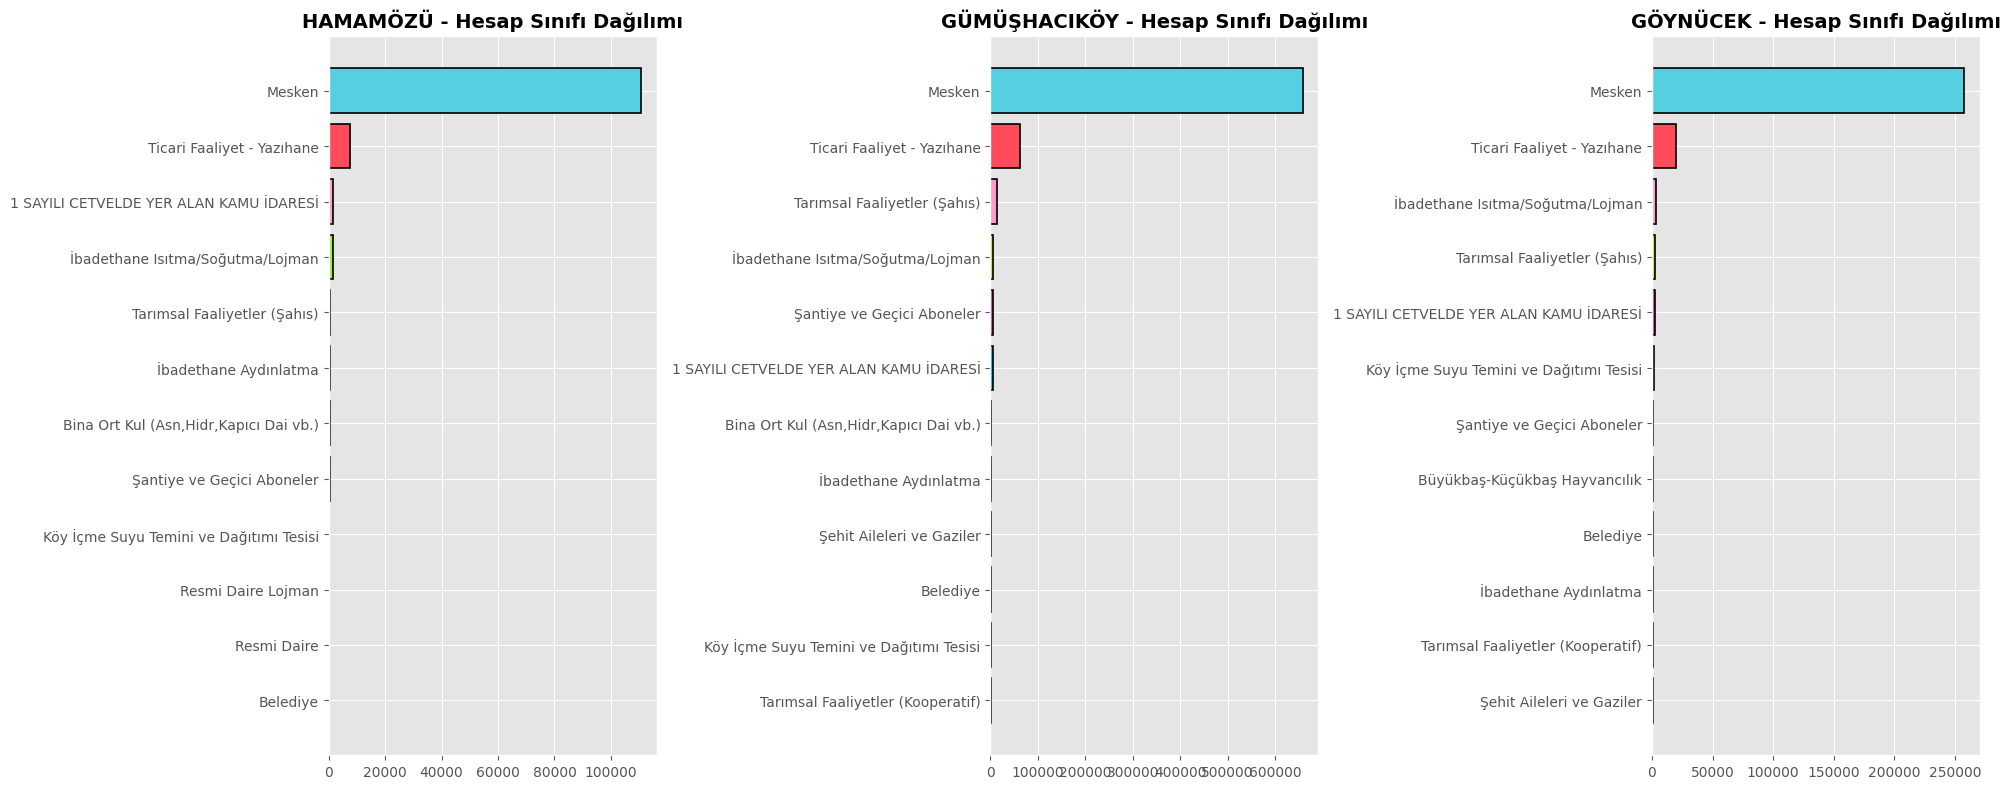

In [5]:
import matplotlib.pyplot as plt

# Grafik stili
plt.style.use("ggplot")  # parlak ve temiz görünüm

fig, axes = plt.subplots(1, 3, figsize=(20,8))

ilceler = ["HAMAMÖZÜ", "GÜMÜŞHACIKÖY", "GÖYNÜCEK"]

# parlak renk paleti
renkler = ["#ff4b5c", "#56cfe1", "#80ed99", "#ffd166", "#b5179e",
           "#ff7b00", "#00b4d8", "#f72585", "#9ef01a", "#ff99c8"]

for i, ilce in enumerate(ilceler):

    data = (
        tahakkuk_clean[tahakkuk_clean["ilce"] == ilce]
        ["Hesap Sınıfı"]
        .value_counts()
        .head(12)
        .sort_values()
    )

    axes[i].barh(
        data.index,
        data.values,
        color=renkler[:len(data)],
        edgecolor="black",
        linewidth=1.2
    )

    axes[i].set_title(f"{ilce} - Hesap Sınıfı Dağılımı", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()



Meskenin diğerlerine göre çok daha fazla veriye sahip olmasından dolayı hesap dağılımlarını tam anlamak ve yorumlamak biraz zorlaşıyor.Bu sebepten dolayı grafikleri meskensiz tekrar yapmaya karar verdim.

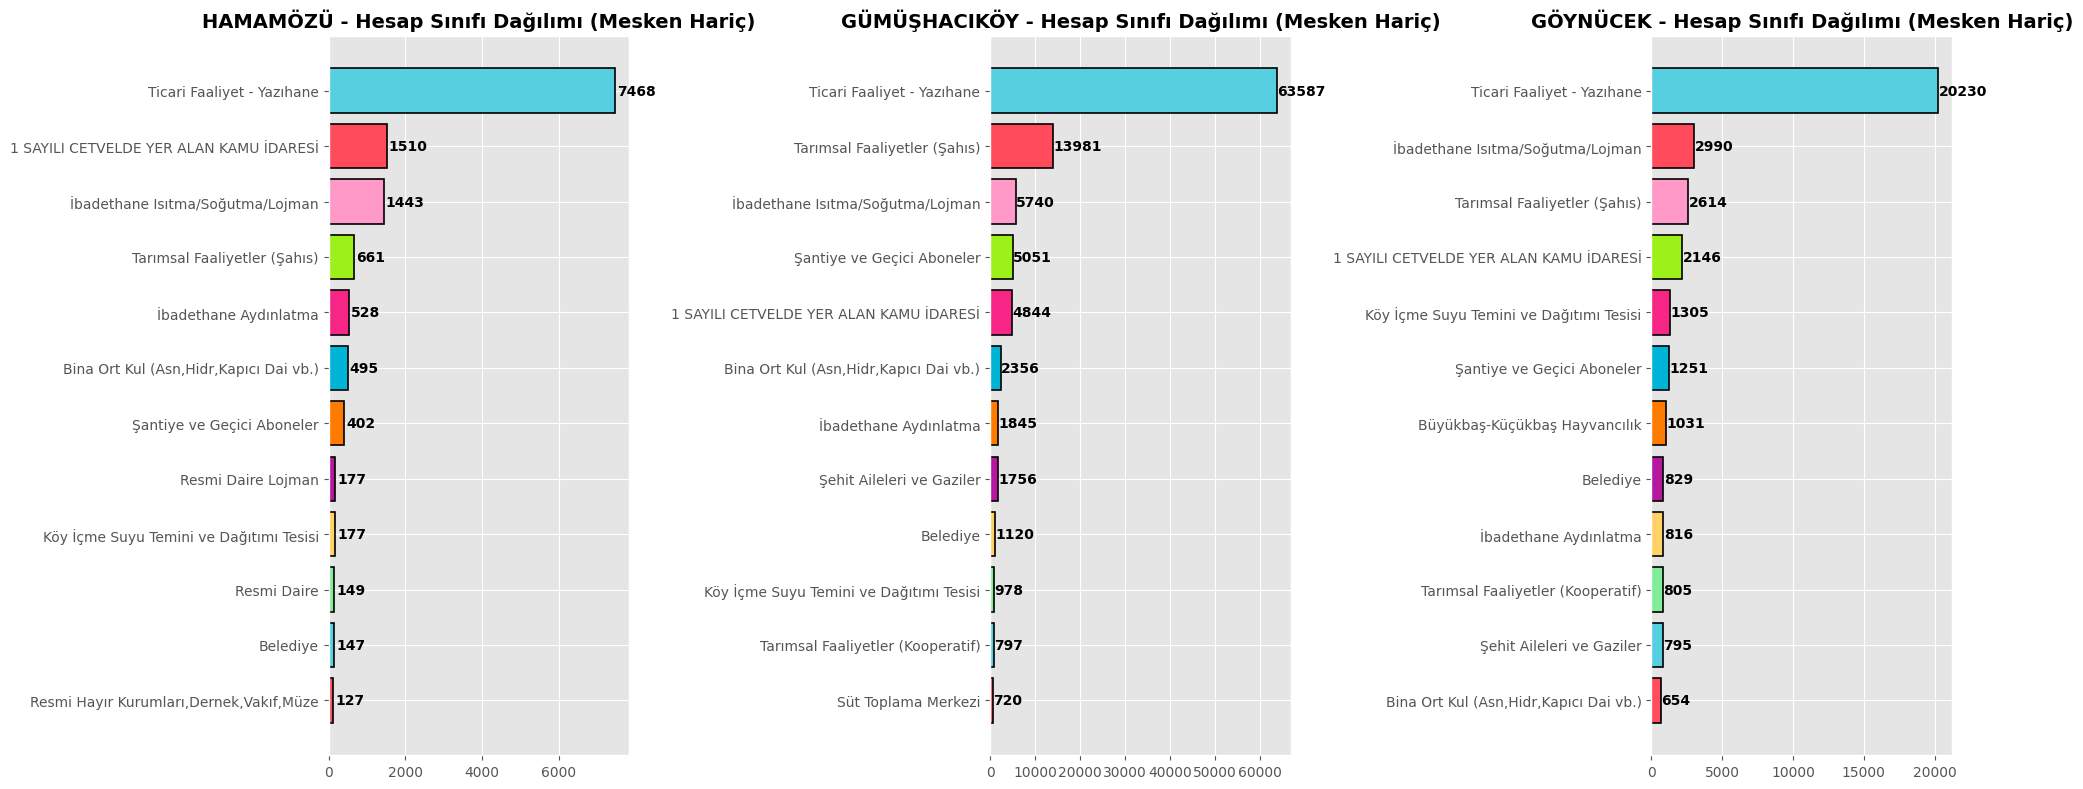

In [6]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

fig, axes = plt.subplots(1, 3, figsize=(20,8))

ilceler = ["HAMAMÖZÜ", "GÜMÜŞHACIKÖY", "GÖYNÜCEK"]

renkler = ["#ff4b5c", "#56cfe1", "#80ed99", "#ffd166", "#b5179e",
           "#ff7b00", "#00b4d8", "#f72585", "#9ef01a", "#ff99c8"]

for i, ilce in enumerate(ilceler):

    data = (
        tahakkuk_clean[
            (tahakkuk_clean["ilce"] == ilce) &
            (tahakkuk_clean["Hesap Sınıfı"] != "Mesken")
        ]["Hesap Sınıfı"]
        .value_counts()
        .head(12)
        .sort_values()
    )

    bars = axes[i].barh(
        data.index,
        data.values,
        color=renkler[:len(data)],
        edgecolor="black",
        linewidth=1.2
    )

    # 🔥 Çubuk ucuna sayı yazdır
    for bar in bars:
        width = bar.get_width()
        axes[i].text(
            width + 50,            # biraz sağa kaydır
            bar.get_y() + bar.get_height()/2,
            f"{int(width)}",
            va="center",
            fontsize=10,
            weight="bold"
        )

    axes[i].set_title(f"{ilce} - Hesap Sınıfı Dağılımı (Mesken Hariç)", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()




Ticari Faaliyet-Yazıhane hesap sınıfının diğerlerine göre belirgin farkını tüm ilçelerde görüyoruz.

In [7]:
tahakkuk_clean['mali_yil_donem'] = pd.to_datetime(tahakkuk_clean['mali_yil_donem'])
tahakkuk_clean['ay'] = tahakkuk_clean['mali_yil_donem'].dt.month

In [8]:
aylik_ortalama = (
    tahakkuk_clean
    .groupby(['ilce','ay'])['kwh']
    .mean()
    .reset_index()
)

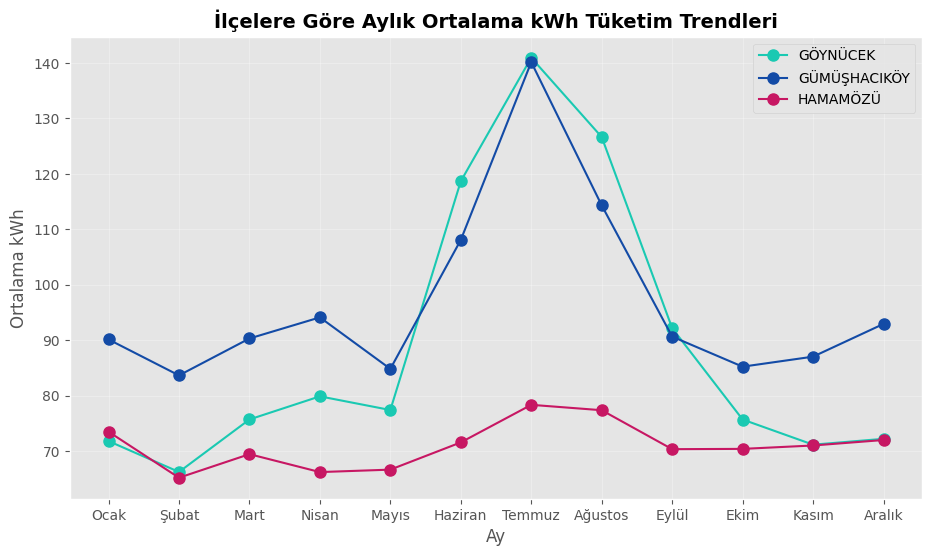

In [9]:
import matplotlib.pyplot as plt

# Canlı ve net renkler (birbirinden kolay ayırt edilir)
renk_map = {
    "HAMAMÖZÜ": "#c71763",      # parlak pembe
    "GÜMÜŞHACIKÖY": "#134ba6",  # elektrik mavisi
    "GÖYNÜCEK": "#1ac9b2"       # neon yeşil
}

ay_isimleri = [
    "Ocak","Şubat","Mart","Nisan","Mayıs","Haziran",
    "Temmuz","Ağustos","Eylül","Ekim","Kasım","Aralık"
]

plt.figure(figsize=(11,6))

for ilce in aylik_ortalama["ilce"].unique():
    data = aylik_ortalama[aylik_ortalama["ilce"] == ilce]

    plt.plot(
        data["ay"],
        data["kwh"],
        marker="o",
        linewidth=1.5,   # çizgiler kalın
        markersize=8,  # noktalar belirgin
        color=renk_map[ilce],
        label=ilce
    )

plt.xticks(range(1,13), ay_isimleri)

plt.title("İlçelere Göre Aylık Ortalama kWh Tüketim Trendleri", fontsize=14, weight="bold")
plt.xlabel("Ay")
plt.ylabel("Ortalama kWh")
plt.legend()
plt.grid(alpha=0.3)

plt.show()



GÖYNÜCEK ve GÜMÜŞHACIKÖY ilçelerinde tüketim yıl boyunca dalgalı seyrediyor ama mayıs ayından başlayarak özellikle Temmuz ayında belirgin bir zirve var (yaklaşık 140 kWh). Bu, yaz aylarında artan klima kullanımı veya tarımsal sulama gibi enerji yoğun faaliyetlerle açıklanabilir.

HAMAMÖZÜ diğer iki ilçeye kıyasla çok daha istikrarlı ve düşük tüketim gösteriyor. Yıl boyunca 70–90 kWh aralığında kalıyor, büyük sıçramalar yok ama yine diğer 2 ilçe gibi temmuz ayında en yüksek değerine ulaşmış.

In [10]:
import pandas as pd

# Ay isimleri map
ay_map = {
    5:"Mayıs",
    6:"Haziran",
    7:"Temmuz",
    8:"Ağustos",
    9:"Eylül"
}

# İstediğimiz aylar
aylar = [5,6,7,8,9]

# Ortalama hesapla
df_ort = (
    tahakkuk_clean
    .groupby(["ilce","ay","Hesap Sınıfı"])["kwh"]
    .mean()
    .reset_index()
)

# Sadece seçili aylar
df_ort = df_ort[df_ort["ay"].isin(aylar)]

# Ay isimlerini ekle
df_ort["Ay"] = df_ort["ay"].map(ay_map)

# Her ilçe + ay için ilk 3
sonuc = (
    df_ort
    .sort_values("kwh", ascending=False)
    .groupby(["ilce","Ay"])
    .head(3)
    .sort_values(["ilce","ay","kwh"], ascending=[True,True,False])
)

display(sonuc[["ilce","Ay","Hesap Sınıfı","kwh"]])


,ilce,Ay,Hesap Sınıfı,kwh
140,GÖYNÜCEK,Mayıs,İçme-Kullanma Suyu (Belediye),14424.230000
130,GÖYNÜCEK,Mayıs,Sanayi,6943.340000
132,GÖYNÜCEK,Mayıs,Tarımsal Faaliyetler (Kooperatif),1146.049634
168,GÖYNÜCEK,Haziran,İçme-Kullanma Suyu (Belediye),14637.660000
161,GÖYNÜCEK,Haziran,Tarımsal Faaliyetler (Kooperatif),7725.603000
159,GÖYNÜCEK,Haziran,Sanayi,4202.840000
194,GÖYNÜCEK,Temmuz,İçme-Kullanma Suyu (Belediye),18556.810000
187,GÖYNÜCEK,Temmuz,Tarımsal Faaliyetler (Kooperatif),11616.464318
185,GÖYNÜCEK,Temmuz,Sanayi,4391.560000
218,GÖYNÜCEK,Ağustos,İçme-Kullanma Suyu (Belediye),18388.333333


Sıçramaların daha fazla yaşandığı Mayıs-Eylül arası dönemdeki her ay etkili olan ilk 3 hesap sınıfının tablosunu yazdırdım. Kabataslak bir yorum yapmak gerekirse Göynücek ve Gümüşhacıköy ilçelerinde Temmuz ayında tarımsal faaliyetlerin devreye girmesiyle tüketim sıçramış. Bu, sulama sezonunun başlamasıyla ilişkili olabilir. Ayrıca yaz aylarında içme-kullanma suyu tüketimi de artıyor.
Hamamözü daha küçük ölçekli bir ilçe olduğu için toplam tüketim düşük. Sanayi ve su tüketimi var ama tarımsal faaliyetler sınırlı. Bu yüzden diğerlerine göre “sıçrama” gözlenmiyor.

<span style="color:#0B3D91; font-size:20px; font-weight:600;">
TAHSİLATLARIN İLÇELERE VE ŞUBELERE GÖRE DAĞILIMI
</span

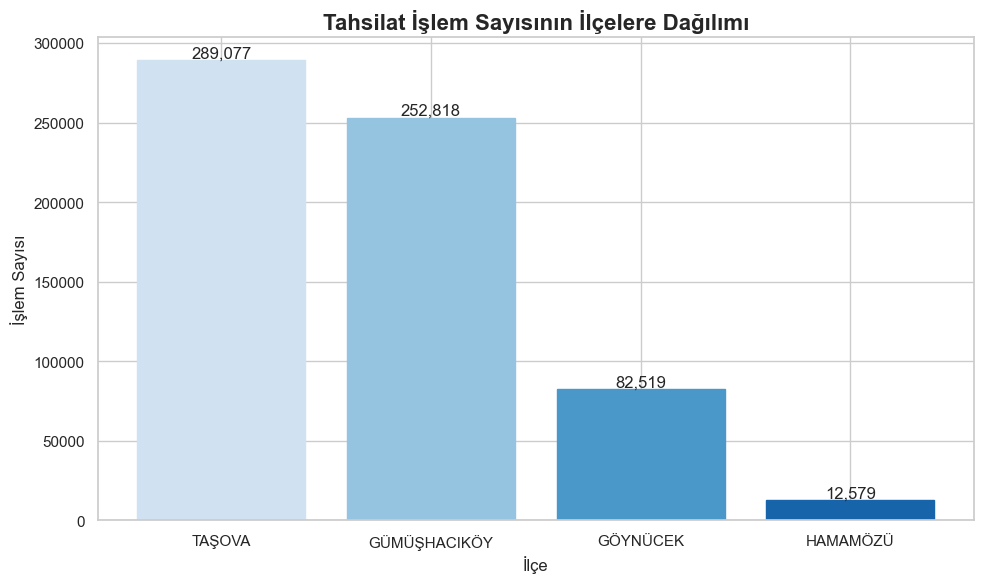

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ilce_sayim = df_tahsilat['İlçe'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(ilce_sayim.index, ilce_sayim.values)

plt.title("Tahsilat İşlem Sayısının İlçelere Dağılımı", fontsize=16, weight="bold")
plt.xlabel("İlçe")
plt.ylabel("İşlem Sayısı")

# Yumuşak renk paleti
colors = sns.color_palette("Blues", len(bars))
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Çubuk üstüne değer yazalım
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{int(height):,}",
             ha='center',
             va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Hizmet yükü dengeli dağılmamış. Toplam tahsilat işlemleri uç noktalarda (Taşova ve Gümüşhacıköy) birikmiş durumda. Bu durum, şirket için risk yönetimini ve personel planlamasını bu iki ilçe üzerine kurmayı zorunlu kılıyor. Hamamözü gibi bölgeler ise operasyonel maliyetlerin (şube giderleri vb.) optimize edilmesi gereken "küçük hacimli, düşük yoğunluklu" alanlar olarak değerlendirilmelidir.

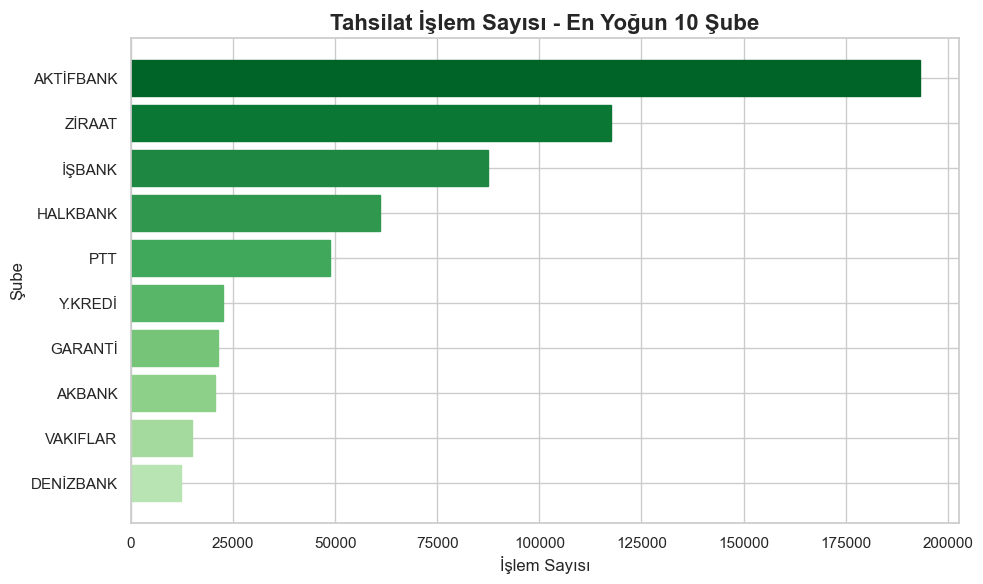

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# İlk 10 şube
sube_sayim = (
    df_tahsilat['Şube']
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

bars = plt.barh(sube_sayim.index, sube_sayim.values)

plt.title("Tahsilat İşlem Sayısı - En Yoğun 10 Şube",
          fontsize=16, weight="bold")
plt.xlabel("İşlem Sayısı")
plt.ylabel("Şube")

# Koyu yeşilden açık yeşile geçiş
colors = plt.cm.Greens(np.linspace(0.9, 0.3, len(bars)))

for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.gca().invert_yaxis()  # En yüksek en üstte

plt.tight_layout()
plt.show()


Müşterilerin dijital bankacılık veya fiziksel şube tercihlerinde AKTİFBANK baskın rol oynamaktadır. İlk 3 banka, toplam tahsilat işlemlerinin yaklaşık %60'ından fazlasını domine etmektedir.

C:\Users\yaren\AppData\Local\Temp\ipykernel_11828\924785017.py:48: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  plt.tight_layout()
C:\Users\yaren\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


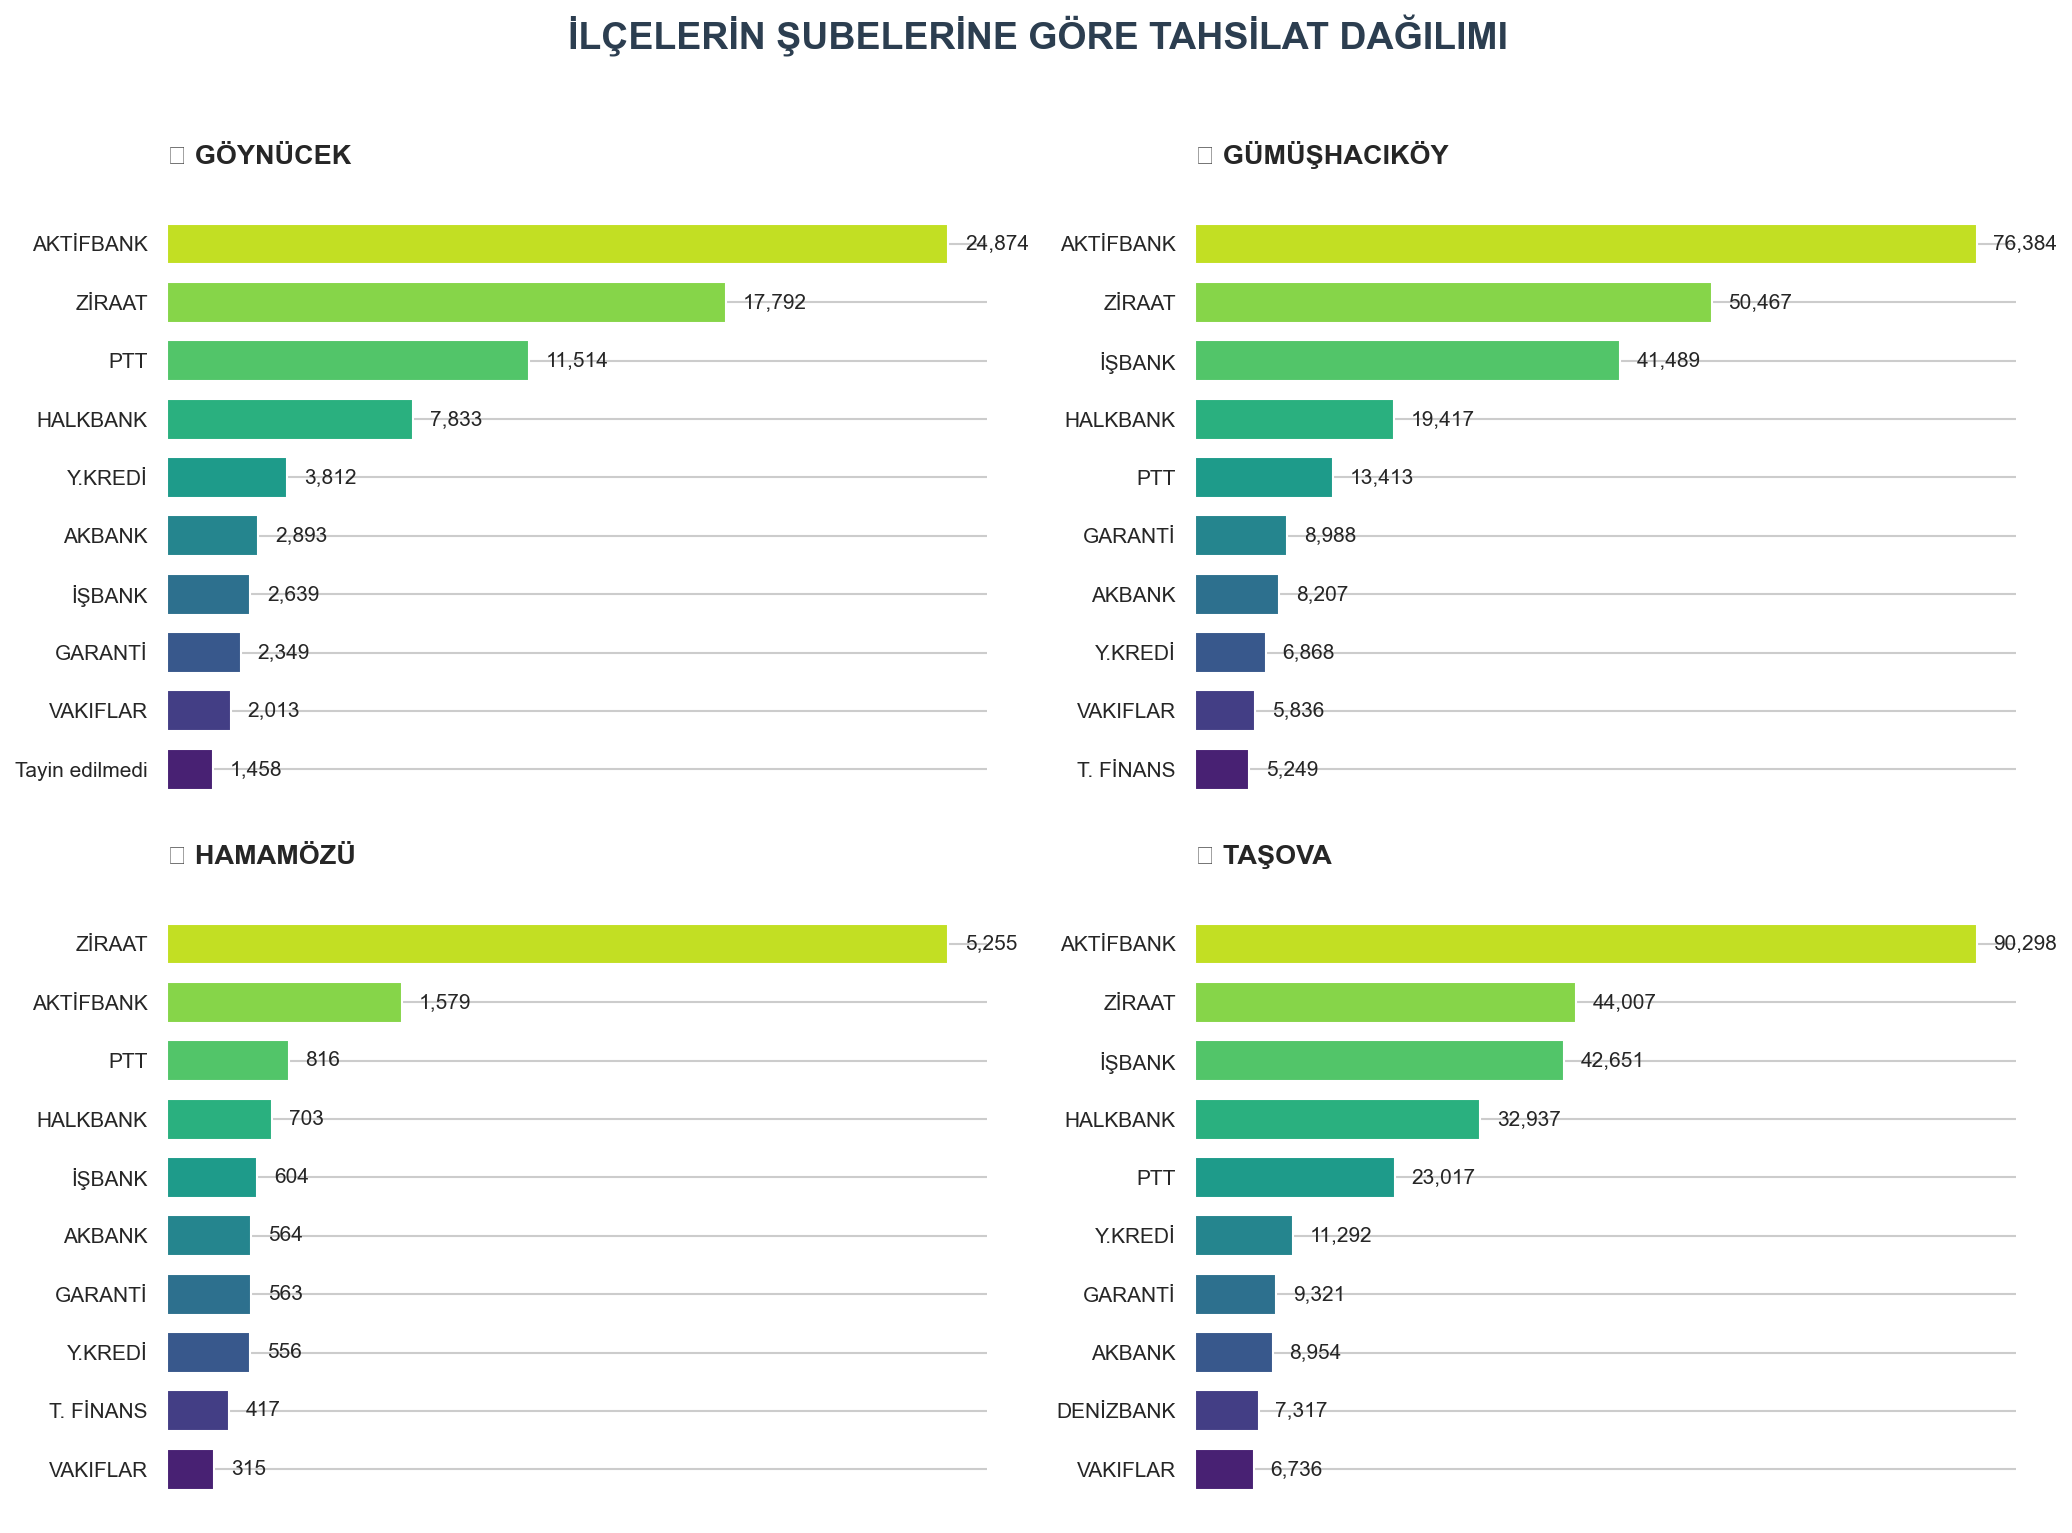

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi hazırla
ilce_sube = df_tahsilat.groupby(["İlçe", "Şube"]).size().reset_index(name="Kayıt Sayısı")
ilceler = ilce_sube["İlçe"].unique()

# Grafik ayarları
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)
axes = axes.flatten()

# Renk paleti (Seaborn'un modern paletlerinden biri)
colors = sns.color_palette("viridis", 10)

for i, ilce in enumerate(ilceler):
    ax = axes[i]
    # Veriyi filtrele ve en yüksek 10 şubeyi al
    data = ilce_sube[ilce_sube["İlçe"] == ilce].sort_values("Kayıt Sayısı", ascending=True).tail(10)
    
    # Yatay bar grafiği
    bars = ax.barh(data["Şube"], data["Kayıt Sayısı"], color=colors, edgecolor='white', height=0.7)
    
    # Başlık ve estetik
    ax.set_title(f"📍 {ilce}", fontsize=13, fontweight="bold", pad=15, loc='left')
    ax.set_xlabel("")
    
    # Bar etiketlerini ekle (Binlik ayraç ile: 1.234)
    ax.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=8, fontsize=10, fontweight='500')
    
    # Gereksiz çizgileri kaldır
    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(False)
    
    # X eksenini tamamen gizle (değerler bar üstünde olduğu için)
    ax.set_xticks([])
    # Y ekseni yazılarını biraz daha belirgin yap
    ax.tick_params(axis='y', labelsize=10)

# --- 4. Boş grafiği gizle ---
if len(ilceler) < len(axes):
    for j in range(len(ilceler), len(axes)):
        axes[j].axis('off')

# Ana başlık
plt.suptitle("İLÇELERİN ŞUBELERİNE GÖRE TAHSİLAT DAĞILIMI", 
             fontsize=18, fontweight="bold", color="#2c3e50", y=1.02)

plt.tight_layout()
plt.show()

<span style="color:#0B3D91; font-size:20px; font-weight:600;">
ZAMANINDA – GEÇ ÖDEME ORANI (PASTA GRAFİĞİ)
</span

In [14]:
print(df_tahsilat1.columns)

Index(['Mali yıl/dönem', 'İl', 'İlçe', 'Söz.hsp.(bağımsız)', 'Hesap Sınıfı',
       'Tahakkuk Tutar', 'Son Ödeme Tarihinden Önceki Tahsilat',
       'Son Ödeme Tarihindeki Tahsilat', 'Son Ödeme (1)', 'Son Ödeme (2)',
       'Son Ödeme (3)', 'Son Ödeme (4)', 'Son Ödeme (5)', 'Son Ödeme (6-10)',
       'Son Ödeme (10-20)', 'Son Ödeme (20-30)', 'Son Ödeme (30-60)',
       'Son Ödeme (60-90)', 'Son Ödeme (90-120)', 'Son Ödeme (120-150)',
       'Son Ödeme (150-180)', 'Son Ödeme (180+)'],
      dtype='object')


In [15]:
df_tahsilat1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 917632 entries, 0 to 917631
Data columns (total 22 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Mali yıl/dönem                        917632 non-null  object 
 1   İl                                    917632 non-null  object 
 2   İlçe                                  917632 non-null  object 
 3   Söz.hsp.(bağımsız)                    917632 non-null  int64  
 4   Hesap Sınıfı                          917632 non-null  object 
 5   Tahakkuk Tutar                        917632 non-null  float64
 6   Son Ödeme Tarihinden Önceki Tahsilat  623908 non-null  float64
 7   Son Ödeme Tarihindeki Tahsilat        328193 non-null  float64
 8   Son Ödeme (1)                         20902 non-null   float64
 9   Son Ödeme (2)                         21664 non-null   float64
 10  Son Ödeme (3)                         18893 non-null   float64
 11  

📊 Müşteri Segmentasyonu ve Karakteristikleri

1. Problem Tanımı

Müşteriler, hem tüketim miktarı hem de ödeme davranışı bakımından farklılık gösteriyor. Bu farklılıkları anlamak, enerji planlaması ve tahsilat yönetimi için kritik. Amaç, müşterileri 3–4 gruba ayırmak ve her grubun karakteristiklerini belirlemektir.

In [16]:
# Zamanında ve geç ödeme sütunları
zamaninda_cols = ['Son Ödeme Tarihinden Önceki Tahsilat', 'Son Ödeme Tarihindeki Tahsilat']
gec_cols = ['Son Ödeme (1)', 'Son Ödeme (2)', 'Son Ödeme (3)', 'Son Ödeme (4)',
            'Son Ödeme (5)', 'Son Ödeme (6-10)', 'Son Ödeme (10-20)', 'Son Ödeme (20-30)',
            'Son Ödeme (30-60)', 'Son Ödeme (60-90)', 'Son Ödeme (90-120)',
            'Son Ödeme (120-150)', 'Son Ödeme (150-180)', 'Son Ödeme (180+)']


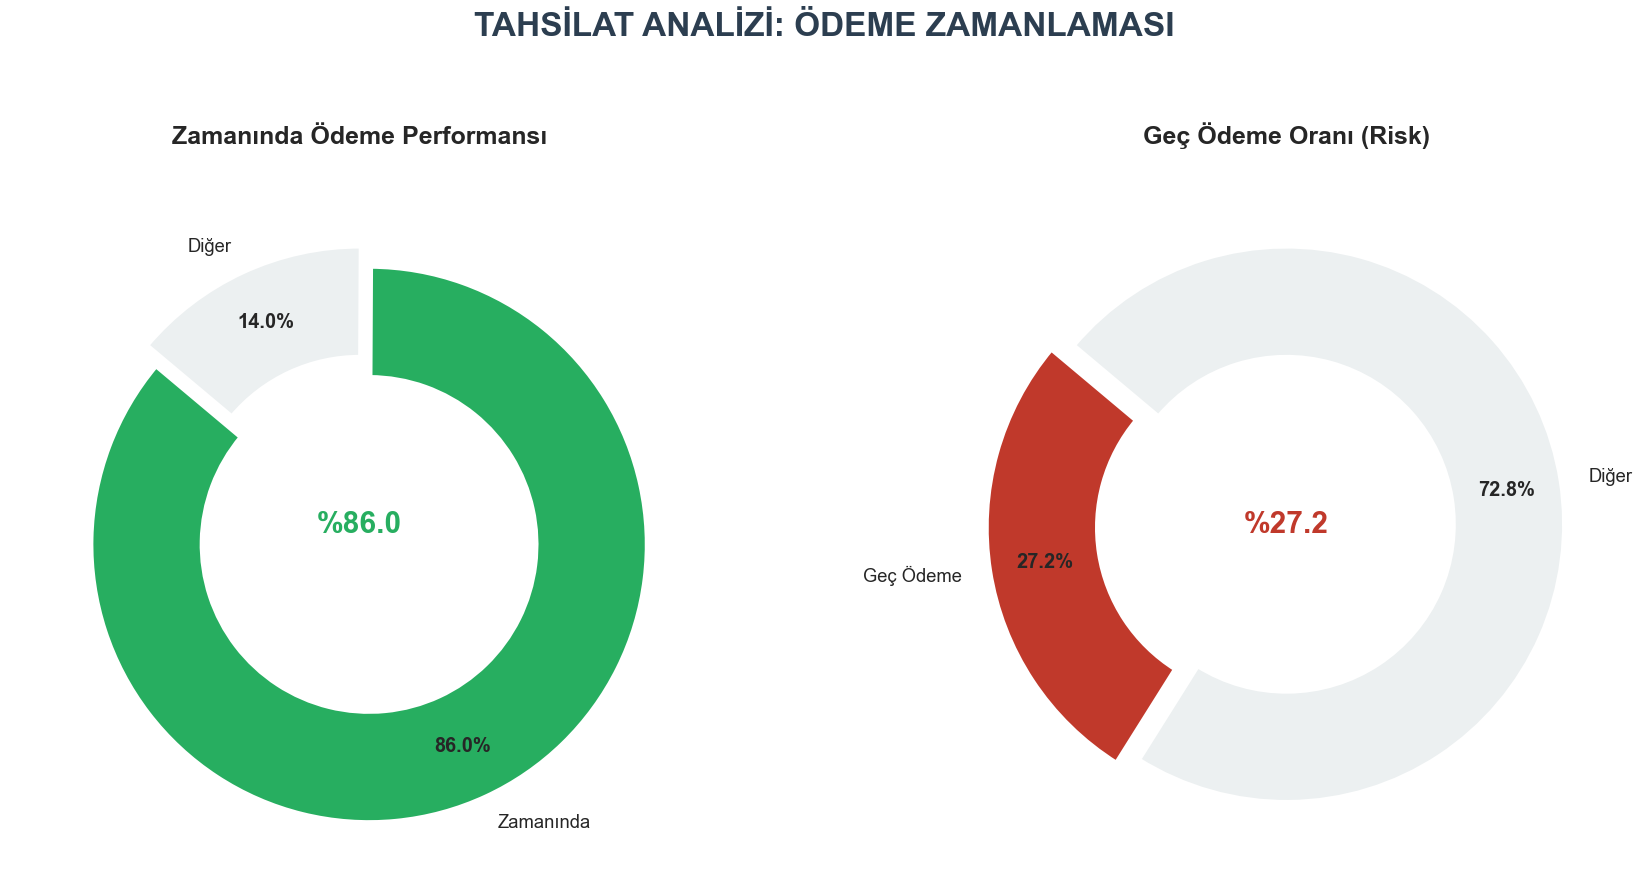

In [17]:
import matplotlib.pyplot as plt

zamaninda_oran = df_tahsilat1[zamaninda_cols].sum(axis=1).gt(0).sum() / len(df_tahsilat1) * 100
gec_oran = df_tahsilat1[gec_cols].sum(axis=1).gt(0).sum() / len(df_tahsilat1) * 100

zamaninda_vals = [zamaninda_oran, 100 - zamaninda_oran]
gec_vals = [gec_oran, 100 - gec_oran]

# --- Yeni Renk Paleti (Modern & Profesyonel) ---
# Pozitif durum için yeşil tonları, negatif durum için kırmızı tonları
colors_z = ['#27ae60', '#ecf0f1']  # Canlı Yeşil ve Açık Gri
colors_g = ['#c0392b', '#ecf0f1']  # Canlı Kırmızı ve Açık Gri

fig, axes = plt.subplots(1, 2, figsize=(15, 7), dpi=120)

# 1. Zamanında Ödeme Donut
wedges1, texts1, autotexts1 = axes[0].pie(
    zamaninda_vals, 
    labels=["Zamanında", "Diğer"], 
    autopct="%1.1f%%", 
    startangle=140, 
    colors=colors_z, 
    explode=(0.08, 0),
    pctdistance=0.80,
    wedgeprops={'width': 0.4, 'edgecolor': 'w', 'linewidth': 3} # Donut kalınlığı ve beyaz sınır
)
axes[0].set_title("Zamanında Ödeme Performansı", fontsize=15, fontweight="bold", pad=20)

# 2. Geç Ödeme Donut
wedges2, texts2, autotexts2 = axes[1].pie(
    gec_vals, 
    labels=["Geç Ödeme", "Diğer"], 
    autopct="%1.1f%%", 
    startangle=140, 
    colors=colors_g, 
    explode=(0.08, 0),
    pctdistance=0.80,
    wedgeprops={'width': 0.4, 'edgecolor': 'w', 'linewidth': 3}
)
axes[1].set_title("Geç Ödeme Oranı (Risk)", fontsize=15, fontweight="bold", pad=20)

# Yazı tiplerini ve merkezdeki sayıları düzenleme
for at in autotexts1 + autotexts2:
    at.set_fontsize(12)
    at.set_weight("bold")

# Grafiğin tam ortasına ana oranı büyükçe yazalım (Dashboard görünümü için)
axes[0].text(0, 0, f"%{zamaninda_oran:.1f}", ha='center', va='center', fontsize=18, fontweight='bold', color='#27ae60')
axes[1].text(0, 0, f"%{gec_oran:.1f}", ha='center', va='center', fontsize=18, fontweight='bold', color='#c0392b')

# Ana Başlık
plt.suptitle("TAHSİLAT ANALİZİ: ÖDEME ZAMANLAMASI", fontsize=20, fontweight="bold", color="#2c3e50", y=1.05)

plt.tight_layout()
plt.show()

Tahsilat verileri kullanılarak, her sözleşmenin ödemeleri zamanında ve geç olarak ayrıldı. Zamanında ödeme, fatura vadesi içinde yapılan tahsilatlar, geç ödeme ise vade sonrasındaki tahsilatlar olarak kabul edildi. Bu sütunlar satır satır toplandı ve sadece 0’dan büyük olanlar sayıldı.
Zamanında ödeme oranı: %86 → Yani tahsilatların büyük çoğunluğu vade içinde yapıldı, ödemeler genel olarak düzenli.
Geç ödeme oranı: %27.2 → Bir kısmı vade sonrası yapıldı, fakat toplam tahsilatın çoğu zamanında gerçekleştiği için işletme açısından büyük risk yok.

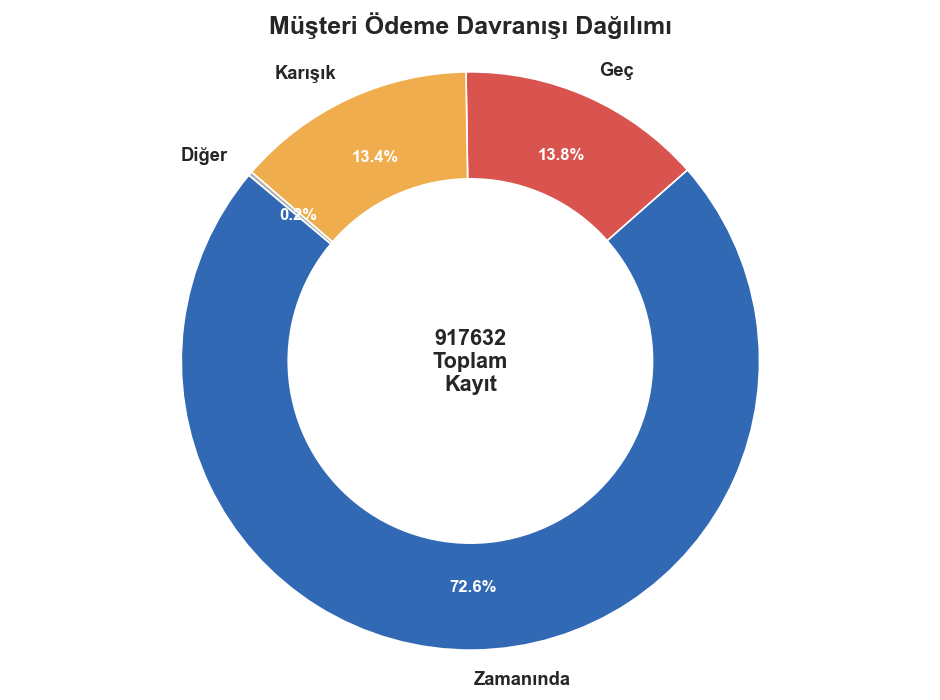

              Adet  Oran (%)
odeme_tipi                  
Zamanında   666215     72.60
Geç         126204     13.75
Karışık     123185     13.42
Diğer         2028      0.22


In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Hesaplamalar ---
df = df_tahsilat1.copy()
df['zamaninda_toplam'] = df[zamaninda_cols].sum(axis=1, skipna=True)
df['gec_toplam'] = df[gec_cols].sum(axis=1, skipna=True)

def odeme_tipi(row):
    if row['zamaninda_toplam'] > 0 and row['gec_toplam'] == 0:
        return 'Zamanında'
    elif row['zamaninda_toplam'] == 0 and row['gec_toplam'] > 0:
        return 'Geç'
    elif row['zamaninda_toplam'] > 0 and row['gec_toplam'] > 0:
        return 'Karışık'
    else:
        return 'Diğer'

df['odeme_tipi'] = df.apply(odeme_tipi, axis=1)
odeme_counts = df['odeme_tipi'].value_counts()

# --- Renkler (Lacivert dahil) ---
colors = {
    "Zamanında": "#3269B5",  # lacivert
    "Geç": "#D9534F",        # kırmızı
    "Karışık": "#F0AD4E",    # turuncu
    "Diğer": "#B0B0B0"       # gri
}

palette = [colors[i] for i in odeme_counts.index]

# --- Grafik ---
plt.figure(figsize=(8,6), dpi=120)

wedges, texts, autotexts = plt.pie(
    odeme_counts,
    labels=odeme_counts.index,
    colors=palette,
    startangle=140,
    autopct='%1.1f%%',
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor='white')
)

centre_circle = plt.Circle((0,0),0.63,fc='white')
plt.gca().add_artist(centre_circle)

plt.setp(texts, size=11, weight="bold")
plt.setp(autotexts, size=10, weight="bold", color="white")

total_records = odeme_counts.sum()

plt.text(0,0,f"{total_records}\nToplam\nKayıt",
         ha='center',va='center',fontsize=13,weight='bold')

plt.title("Müşteri Ödeme Davranışı Dağılımı", fontsize=15, weight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame({
    'Adet': odeme_counts,
    'Oran (%)': (odeme_counts / total_records * 100).round(2)
})

print(summary_df)

Önceki genel pasta grafiğine göre ödemelerin %86’sı zamanında yapılmış görünüyordu. Ancak daha ayrıntılı bu grafikte, zamanında ödeme yapanların %72.6’sı tüm ödemelerini zamanında tamamlamış, %13.4’ü ise bazı ödemelerini sonraki tarihe bırakmış.

<span style="color:#0B3D91; font-size:20px; font-weight:600;">
KWH TÜKETİM DAĞILIMI 
</span

c:\Users\yaren\Downloads\Lib\site-packages\pandas\core\nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\yaren\AppData\Local\Temp\ipykernel_11828\3182416622.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\yaren\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


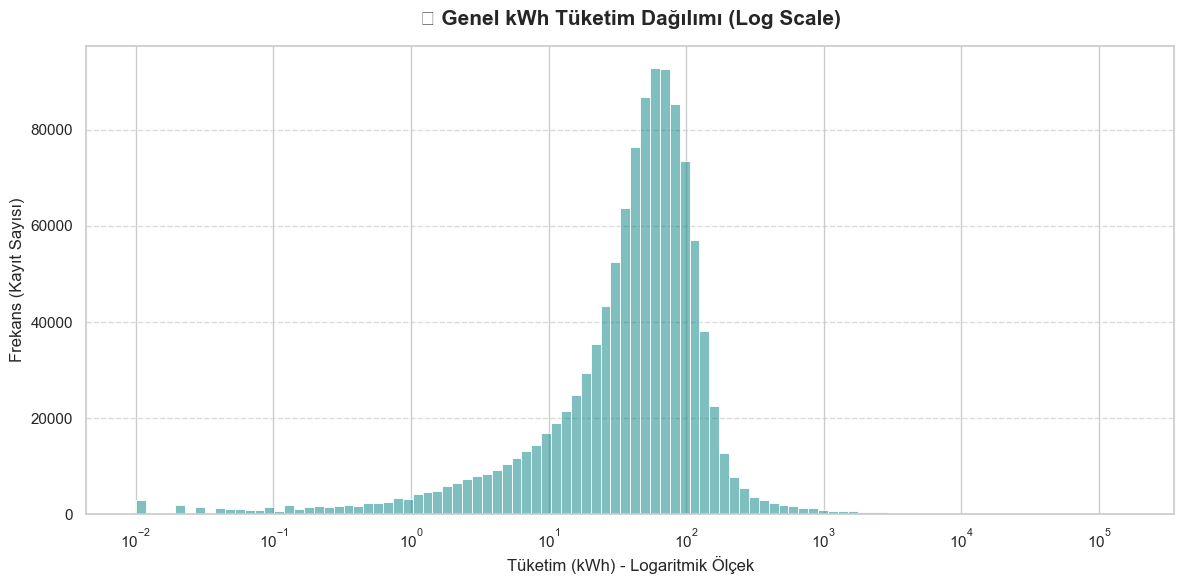

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik boyutunu ayarla
plt.figure(figsize=(12, 6))

# Histogram ve Yoğunluk Eğrisi (KDE)
# log_scale=True parametresi ile ekseni doğrudan logaritmik yapıyoruz
sns.histplot(data=tahakkuk_clean, x='kwh', bins=100, kde=True, color='teal', log_scale=True)

# Başlık ve Etiketler
plt.title('📊 Genel kWh Tüketim Dağılımı (Log Scale)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Tüketim (kWh) - Logaritmik Ölçek', fontsize=12)
plt.ylabel('Frekans (Kayıt Sayısı)', fontsize=12)

# Izgara çizgilerini ekleyerek okunabilirliği artıralım
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Dağılım grafiğine baktığımızda kwh tüketimlerinin genel olarak 10 ila 100 arasındaki değerlerde yoğunlaştığını söyleyebiliriz. Verideki yüksek kwh değerleri ise tam olarak gözükmemiş bu yüzden grafiği tekrar çizdiriyoruz.

C:\Users\yaren\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


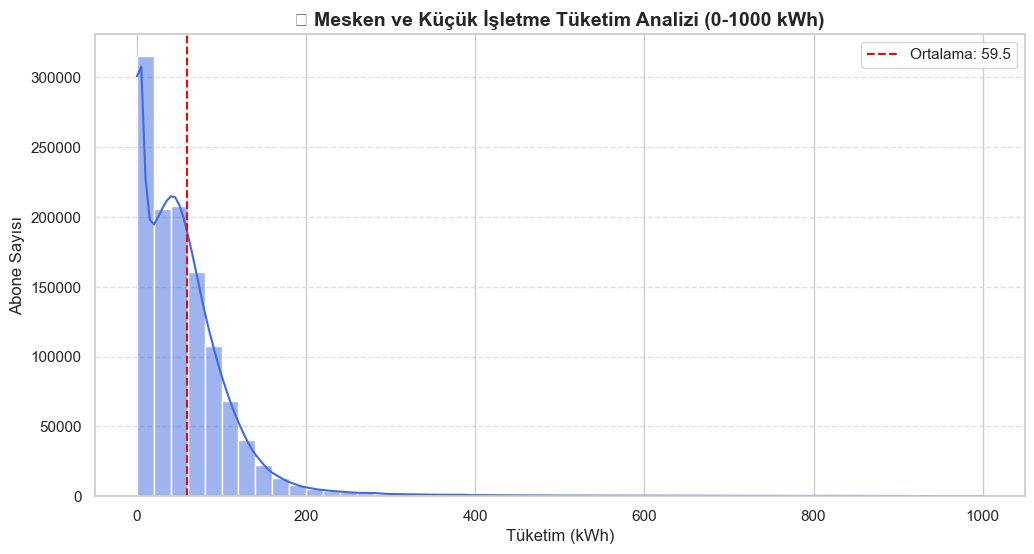

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 0-1000 kWh aralığını filtrele
df_zoom = tahakkuk_clean[tahakkuk_clean['kwh'] <= 1000]

plt.figure(figsize=(12, 6))
sns.histplot(data=df_zoom, x='kwh', bins=50, kde=True, color='royalblue')

plt.title('🏠 Mesken ve Küçük İşletme Tüketim Analizi (0-1000 kWh)', fontsize=14, fontweight='bold')
plt.xlabel('Tüketim (kWh)')
plt.ylabel('Abone Sayısı')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Ortalama tüketimi işaretle
plt.axvline(df_zoom['kwh'].mean(), color='red', linestyle='--', label=f"Ortalama: {df_zoom['kwh'].mean():.1f}")
plt.legend()

plt.show()

C:\Users\yaren\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127981 (\N{FACTORY}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


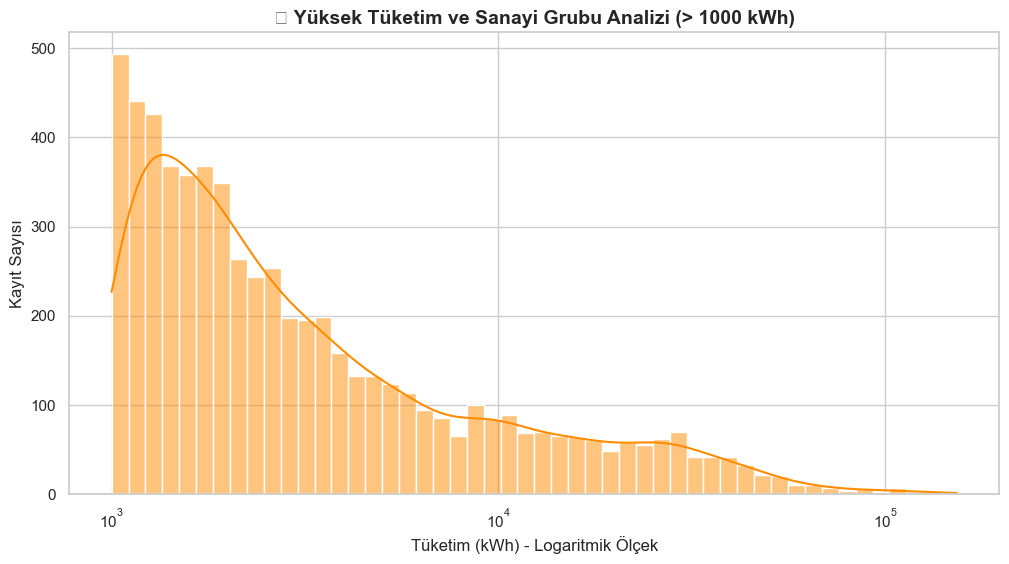

In [21]:
# 1000 kWh üzerini filtrele
df_high = tahakkuk_clean[tahakkuk_clean['kwh'] > 1000]

plt.figure(figsize=(12, 6))
# Burada tekrar log scale kullanıyoruz çünkü 1001 ile 150.000 arasında hala uçurum var
sns.histplot(data=df_high, x='kwh', bins=50, kde=True, color='darkorange', log_scale=True)

plt.title('🏭 Yüksek Tüketim ve Sanayi Grubu Analizi (> 1000 kWh)', fontsize=14, fontweight='bold')
plt.xlabel('Tüketim (kWh) - Logaritmik Ölçek')
plt.ylabel('Kayıt Sayısı')

plt.show()

<span style="color:#0B3D91; font-size:20px; font-weight:600;">
GENEL KWH BOXPLOT GRAFİĞİ
</span

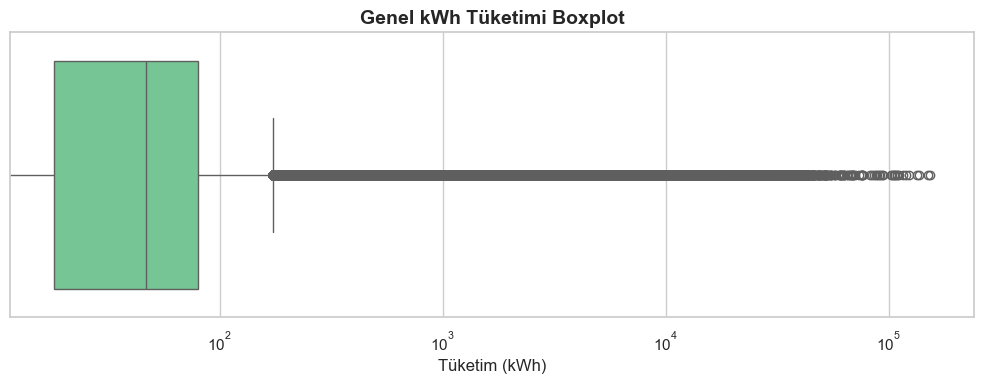

In [22]:
plt.figure(figsize=(10,4))

sns.boxplot(
    data=tahakkuk_clean,
    x="kwh",
    color="#68D391",
    showfliers=True
)

plt.xscale("log")

plt.title("Genel kWh Tüketimi Boxplot", fontsize=14, fontweight="bold")
plt.xlabel("Tüketim (kWh)")

plt.tight_layout()
plt.show()

📌Veri setinde 10 kWh ile 100.000+ kWh arasında devasa bir fark olduğu için, tüm müşteri gruplarını aynı düzlemde analiz edebilmek adına logaritmik ölçek tercih edilmiştir. Bu yöntem, küçük tüketimli meskenlerin grafik içinde kaybolmasını engellemiştir.

<span style="color:#0B3D91; font-size:20px; font-weight:600;">
İLÇELERE GÖRE KWH BOXPLOT GRAFİKLERİ
</span

C:\Users\yaren\AppData\Local\Temp\ipykernel_11828\663442372.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


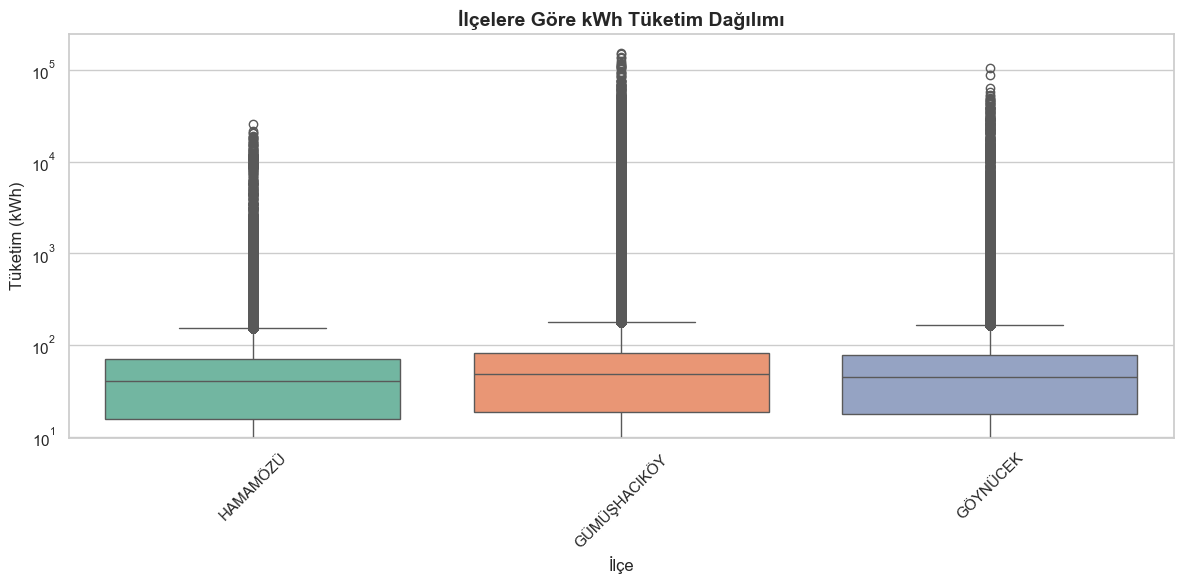

In [23]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=tahakkuk_clean,
    x="ilce",
    y="kwh",
    palette="Set2",
    showfliers=True
)

plt.yscale("log")

plt.title("İlçelere Göre kWh Tüketim Dağılımı", fontsize=14, fontweight="bold")
plt.xlabel("İlçe")
plt.ylabel("Tüketim (kWh)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()